In [1]:
# ----- Libraries -----
import pandas as pd                # dataframes and CSV IO
import numpy as np                 # numeric helpers
import matplotlib.pyplot as plt    # plotting
import seaborn as sns              # nicer plots
import sqlite3                     # optional: connect to local DB

sns.set(style="whitegrid")         # set style (optional)


In [2]:
df = pd.read_csv("superstore.csv", encoding="latin1")


In [3]:
# ----- Basic info and cleaning -----
# 1) shape and columns
print("rows,cols:", df.shape)
print(df.columns.tolist())

# 2) rename columns for consistency (optional)
df.columns = [c.strip().replace(' ', '_') for c in df.columns]

# 3) check missing values
print(df.isnull().sum())

# 4) drop rows missing critical values (OrderID, Sales)
df = df.dropna(subset=['Order_ID','Sales'])

# 5) convert dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce')
# If date conversion created NaT, you migt drop or fill them:
df = df.dropna(subset=['Order_Date'])


rows,cols: (9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
# ----- Derived columns -----
# profit margin (Profit / Sales). Avoid division by 0
df['profit_margin'] = df.apply(lambda r: r['Profit'] / r['Sales'] if r['Sales'] and r['Sales'] != 0 else np.nan, axis=1)

# order month for seasonality
df['Order_Month'] = df['Order_Date'].dt.to_period('M').astype(str)

# lead time: days between order and ship (proxy for supply chain / inventory velocity)
df['lead_time_days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

# show sample
df[['Order_ID','Order_Date','Ship_Date','lead_time_days','Sales','Profit','profit_margin']].head()


,Order_ID,Order_Date,Ship_Date,lead_time_days,Sales,Profit,profit_margin
0,CA-2016-152156,2016-11-08,2016-11-11,3,261.9600,41.9136,0.1600
1,CA-2016-152156,2016-11-08,2016-11-11,3,731.9400,219.5820,0.3000
2,CA-2016-138688,2016-06-12,2016-06-16,4,14.6200,6.8714,0.4700
3,US-2015-108966,2015-10-11,2015-10-18,7,957.5775,-383.0310,-0.4000
4,US-2015-108966,2015-10-11,2015-10-18,7,22.3680,2.5164,0.1125


In [6]:
# ----- Aggregations for visuals -----
# profit by category & subcategory
cat_profit = df.groupby('Category').agg(total_sales=('Sales','sum'),
                                        total_profit=('Profit','sum'),
                                        avg_margin=('profit_margin','mean')).reset_index()

subcat_profit = df.groupby('Sub-Category').agg(total_sales=('Sales','sum'),
                                               total_profit=('Profit','sum'),
                                               avg_margin=('profit_margin','mean')).reset_index().sort_values('total_profit', ascending=False)

# monthly trend
monthly = df.groupby('Order_Month').agg(total_sales=('Sales','sum'), total_profit=('Profit','sum')).reset_index()

# regional summary
region_summary = df.groupby('Region').agg(total_sales=('Sales','sum'), total_profit=('Profit','sum')).reset_index()

# lead_time vs profit per order (for scatter)
lead_profit = df[['lead_time_days','Profit','Sales','Category']].dropna(subset=['lead_time_days'])


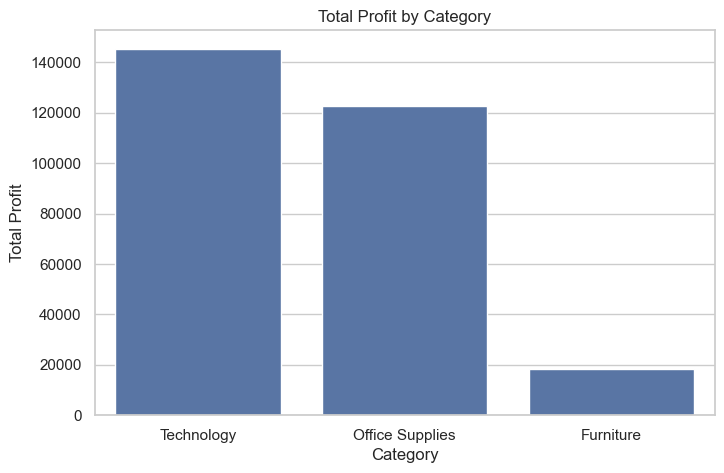

In [7]:
# ----- Visualizations -----
plt.figure(figsize=(8,5))
sns.barplot(data=cat_profit.sort_values('total_profit',ascending=False), x='Category', y='total_profit')
plt.title('Total Profit by Category')
plt.ylabel('Total Profit')
plt.show()


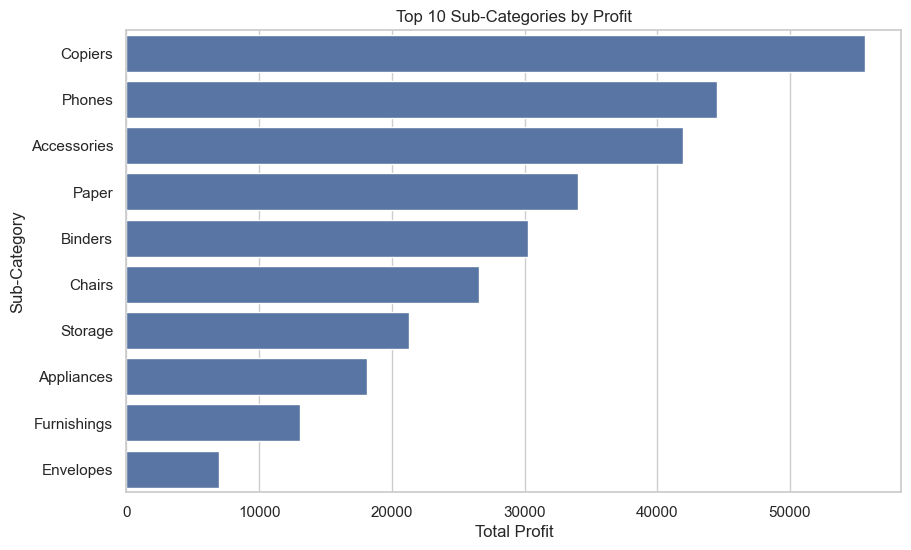

In [8]:
# Top 10 sub-categories by profit (horizontal bar)
plt.figure(figsize=(10,6))
top10 = subcat_profit.head(10)
sns.barplot(x='total_profit', y='Sub-Category', data=top10)
plt.title('Top 10 Sub-Categories by Profit')
plt.xlabel('Total Profit')
plt.show()


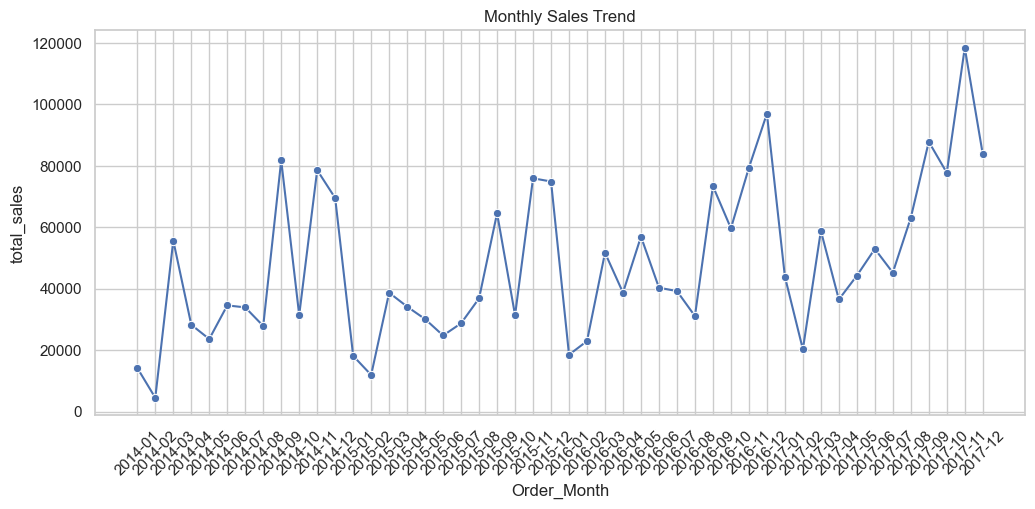

In [9]:
# Monthly sales trend
plt.figure(figsize=(12,5))
sns.lineplot(x='Order_Month', y='total_sales', data=monthly, marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()


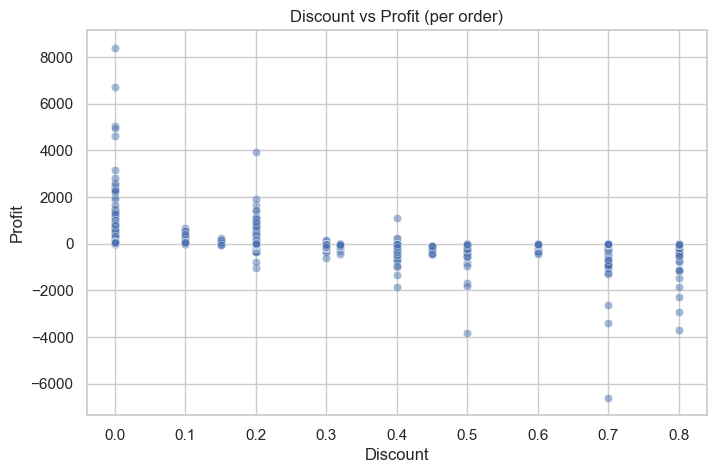

In [10]:
# Discount vs Profit scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.5)
plt.title('Discount vs Profit (per order)')
plt.show()


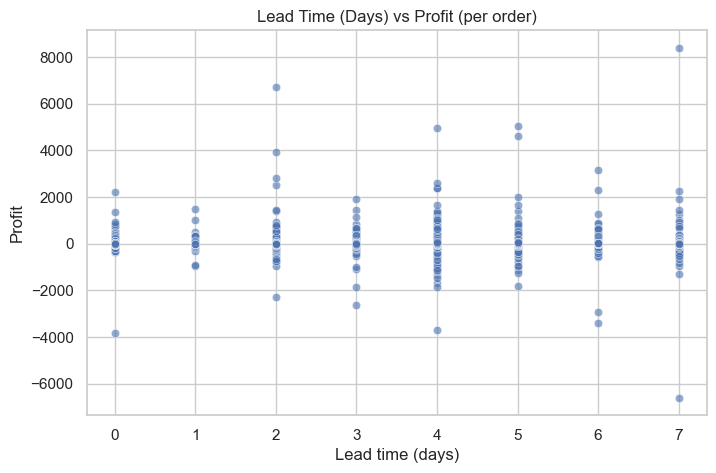

In [11]:
# Lead time (proxy for inventory turnover) vs Profit scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x='lead_time_days', y='Profit', data=lead_profit, alpha=0.6)
plt.title('Lead Time (Days) vs Profit (per order)')
plt.xlabel('Lead time (days)')
plt.ylabel('Profit')
plt.show()


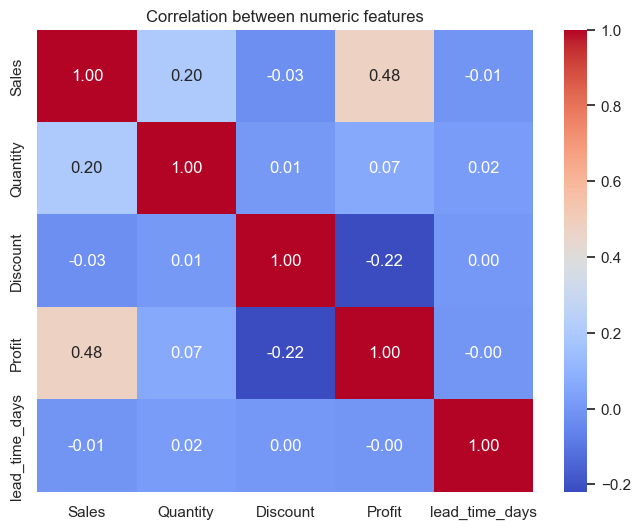

In [12]:
# Correlation matrix for numeric columns (Sales, Quantity, Discount, Profit, lead_time_days if available)
num_cols = ['Sales','Quantity','Discount','Profit']
if 'lead_time_days' in df.columns:
    num_cols.append('lead_time_days')
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation between numeric features')
plt.show()


In [14]:
# ----- Inventory days correlation (two cases) -----
# CASE A: You have an inventory table with 'avg_inventory' and 'cogs' (cost of goods sold).
# Suppose you loaded inventory CSV as inv_df with columns: ProductID, avg_inventory, cogs
# days_inventory_outstanding = (avg_inventory / cogs) * 365

# If inventory data exists:
# inv_df['days_inventory_outstanding'] = inv_df['avg_inventory'] / inv_df['cogs'] * 365
# merged = pd.merge(inv_df, product_profit_df, on='ProductID')
# correlation = merged['days_inventory_outstanding'].corr(merged['profit_margin'])
# print("Correlation DIO vs profit_margin:", correlation)

# CASE B: If not, use 'lead_time_days' as a proxy for inventory velocity:
if 'lead_time_days' in df.columns:
    # compute per-product average lead_time and profit_margin
    product_stats = df.groupby('Product_Name').agg(
        avg_lead_time=('lead_time_days','mean'),
        avg_profit_margin=('profit_margin','mean'),
        total_sales=('Sales','sum'),
        total_profit=('Profit','sum')
    ).dropna().reset_index()
    # correlation: avg_lead_time vs avg_profit_margin
    corr_proxy = product_stats['avg_lead_time'].corr(product_stats['avg_profit_margin'])
    print("Proxy correlation (avg lead time vs avg profit margin):", corr_proxy)


Proxy correlation (avg lead time vs avg profit margin): 0.04917357059260735


In [15]:
# Save cleaned dataset for Power BI import
df.to_csv('clean_superstore.csv', index=False)
print("clean_superstore.csv saved.")


clean_superstore.csv saved.
